In [1]:
# CELL 1 - imports & paths
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from collections import OrderedDict

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, roc_auc_score
)

# Ensure directories exist
os.makedirs("../models", exist_ok=True)
os.makedirs("../data", exist_ok=True)
METRICS_FILE = "../data/comparison_metrics.json"

print("Working dirs OK. Models in ../models, data in ../data")



Working dirs OK. Models in ../models, data in ../data


In [2]:
# CELL 2 - load encoded data and targets
X2 = pd.read_csv("../data/BTS2_encoded.csv")  # Old (baseline / offline)
y2 = pd.read_csv("../data/BTS2_target.csv")

X1 = pd.read_csv("../data/BTS1_encoded.csv")  # New (future / incremental)
y1 = pd.read_csv("../data/BTS1_target.csv")

# Flatten label Series if they are DataFrame columns
if isinstance(y2, pd.DataFrame):
    y2 = y2.iloc[:, 0]
if isinstance(y1, pd.DataFrame):
    y1 = y1.iloc[:, 0]

print("BTS2 shape:", X2.shape, "BTS2 labels:", y2.shape)
print("BTS1 shape:", X1.shape, "BTS1 labels:", y1.shape)


BTS2 shape: (728316, 112) BTS2 labels: (728316,)
BTS1 shape: (487574, 112) BTS1 labels: (487574,)


In [3]:
# CELL 3 - train/test split on BTS2 and scaling (use BTS2 stats for BTS1 transform)
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale BTS1 using the same scaler
X1_scaled = scaler.transform(X1)

# Save scaler for other notebooks
joblib.dump(scaler, "../models/scaler.pkl")
print("Saved scaler to ../models/scaler.pkl")



X_train: (582652, 112) X_test: (145664, 112)
Saved scaler to ../models/scaler.pkl


In [4]:
# CELL 4 - utility to compute metrics robustly (binary or multiclass)
def compute_metrics_for_model(model, X_test_scaled, y_test, X_new_scaled, y_new):
    """
    Returns:
        acc_old (accuracy on X_test_scaled),
        acc_new (accuracy on X_new_scaled),
        auroc (roc-auc on combined set; supports binary and multiclass),
        f1 (weighted F1 on combined set)
    """
    # Predictions
    preds_old = model.predict(X_test_scaled)
    preds_new = model.predict(X_new_scaled)

    acc_old = accuracy_score(y_test, preds_old)
    acc_new = accuracy_score(y_new, preds_new)

    # Combined sets for AUROC/F1
    X_comb = np.vstack([X_test_scaled, X_new_scaled])
    y_comb = np.concatenate([y_test.ravel(), y_new.ravel()])

    # Try to get probabilities; fallback to decision_function when available.
    probs = None
    try:
        probs = model.predict_proba(X_comb)
    except Exception:
        # Some classifiers (SVM without probability=True) expose decision_function
        try:
            df = model.decision_function(X_comb)
            # If binary, decision_function returns shape (n_samples,), convert to two-column prob-like
            if df.ndim == 1:
                # Use sigmoid to map to [0,1] for pseudo-prob for AUROC
                probs = np.vstack([1 / (1 + np.exp(-df)), 1 / (1 + np.exp(df))]).T
            else:
                # multiclass decision scores; convert to probabilities via softmax
                exp = np.exp(df - np.max(df, axis=1, keepdims=True))
                probs = exp / np.sum(exp, axis=1, keepdims=True)
        except Exception:
            probs = None

    # Compute AUROC robustly:
    if probs is None:
        # If no probabilities available, AUROC can't be computed reliably
        auroc = float('nan')
    else:
        # If binary classification, select column for positive class
        if probs.shape[1] == 2:
            auroc = roc_auc_score(y_comb, probs[:, 1])
        else:
            # multiclass: use 'ovr' macro-average
            auroc = roc_auc_score(y_comb, probs, multi_class='ovr', average='macro')

    # F1 (weighted) on combined
    preds_comb = np.concatenate([preds_old, preds_new])
    f1 = f1_score(y_comb, preds_comb, average='weighted')

    return acc_old, acc_new, auroc, f1



In [5]:
# CELL 5 - define models and train them; compute metrics and save models + metrics
models = OrderedDict({
    "SVM": SVC(max_iter=1000, probability=True, random_state=42),  # probability=True for predict_proba
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(128,), solver='adam', alpha=1e-4, max_iter=500, random_state=42),
    "Perceptron": Perceptron(max_iter=1000, random_state=42),
})

# Dictionaries to store results for plotting
results_bts2 = {}
results_bts1 = {}

# Loop train/evaluate/save
for name, model in models.items():
    print(f"\n=== Training {name} on BTS2 ===")
    model.fit(X_train_scaled, y_train.values.ravel())

    acc_test = accuracy_score(y_test, model.predict(X_test_scaled))
    acc_bts1 = accuracy_score(y1, model.predict(X1_scaled))

    results_bts2[name] = acc_test
    results_bts1[name] = acc_bts1

    print(f"{name} - BTS2 Test Accuracy: {acc_test:.4f}")
    print(f"{name} - BTS1 (No Drift) Accuracy: {acc_bts1:.4f}")
    print("Confusion matrix (BTS1):")
    print(confusion_matrix(y1, model.predict(X1_scaled)))
    print("\nClassification report (BTS1):")
    print(classification_report(y1, model.predict(X1_scaled)))

    # Save model
    model_path = f"../models/{name.replace(' ', '_').lower()}_model.pkl"
    joblib.dump(model, model_path)
    print(f"Saved model to {model_path}")

    # Compute additional metrics (AUROC, F1) and forgetting rate for this model
    acc_old, acc_new, auroc, f1 = compute_metrics_for_model(model, X_test_scaled, y_test, X1_scaled, y1)
    forgetting_rate = acc_old - acc_new

    # Save metrics to JSON file (update existing file)
    try:
        with open(METRICS_FILE, 'r') as f:
            metrics_dict = json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        metrics_dict = {}

    metrics_dict[name] = {
        'accuracy_data': {'BTS2 (Old)': round(acc_old, 4), 'BTS1 (New)': round(acc_new, 4)},
        'metrics_data': {'AUROC': round(float(auroc), 4) if not np.isnan(auroc) else None,
                        'F1-Score': round(float(f1), 4),
                        'Forgetting Rate': round(float(forgetting_rate), 4)}
    }

    with open(METRICS_FILE, 'w') as f:
        json.dump(metrics_dict, f, indent=4)

    print(f"Saved metrics for {name} to {METRICS_FILE}")



=== Training SVM on BTS2 ===


/Users/roskat/Desktop/CS427/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM - BTS2 Test Accuracy: 1.0000
SVM - BTS1 (No Drift) Accuracy: 0.9999
Confusion matrix (BTS1):
[[ 70778      0]
 [    68 416728]]

Classification report (BTS1):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     70778
   Malicious       1.00      1.00      1.00    416796

    accuracy                           1.00    487574
   macro avg       1.00      1.00      1.00    487574
weighted avg       1.00      1.00      1.00    487574

Saved model to ../models/svm_model.pkl


/var/folders/v3/9vhsqmm10zd5wzyzbk2jb9wr0000gn/T/ipykernel_68075/1469720569.py:19: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_comb = np.concatenate([y_test.ravel(), y_new.ravel()])


Saved metrics for SVM to ../data/comparison_metrics.json

=== Training Logistic Regression on BTS2 ===
Logistic Regression - BTS2 Test Accuracy: 1.0000
Logistic Regression - BTS1 (No Drift) Accuracy: 1.0000
Confusion matrix (BTS1):
[[ 70775      3]
 [     0 416796]]

Classification report (BTS1):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     70778
   Malicious       1.00      1.00      1.00    416796

    accuracy                           1.00    487574
   macro avg       1.00      1.00      1.00    487574
weighted avg       1.00      1.00      1.00    487574

Saved model to ../models/logistic_regression_model.pkl


...

Saved metrics for Logistic Regression to ../data/comparison_metrics.json

=== Training MLP on BTS2 ===
MLP - BTS2 Test Accuracy: 1.0000
MLP - BTS1 (No Drift) Accuracy: 1.0000
Confusion matrix (BTS1):
[[ 70777      1]
 [     1 416795]]

Classification report (BTS1):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     70778
   Malicious       1.00      1.00      1.00    416796

    accuracy                           1.00    487574
   macro avg       1.00      1.00      1.00    487574
weighted avg       1.00      1.00      1.00    487574

Saved model to ../models/mlp_model.pkl


/var/folders/v3/9vhsqmm10zd5wzyzbk2jb9wr0000gn/T/ipykernel_68075/1469720569.py:19: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_comb = np.concatenate([y_test.ravel(), y_new.ravel()])


Saved metrics for MLP to ../data/comparison_metrics.json

=== Training Perceptron on BTS2 ===
Perceptron - BTS2 Test Accuracy: 1.0000
Perceptron - BTS1 (No Drift) Accuracy: 0.9996
Confusion matrix (BTS1):
[[ 70762     16]
 [   181 416615]]

Classification report (BTS1):
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     70778
   Malicious       1.00      1.00      1.00    416796

    accuracy                           1.00    487574
   macro avg       1.00      1.00      1.00    487574
weighted avg       1.00      1.00      1.00    487574

Saved model to ../models/perceptron_model.pkl


/var/folders/v3/9vhsqmm10zd5wzyzbk2jb9wr0000gn/T/ipykernel_68075/1469720569.py:19: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_comb = np.concatenate([y_test.ravel(), y_new.ravel()])
/var/folders/v3/9vhsqmm10zd5wzyzbk2jb9wr0000gn/T/ipykernel_68075/1469720569.py:32: RuntimeWarning: overflow encountered in exp
  probs = np.vstack([1 / (1 + np.exp(-df)), 1 / (1 + np.exp(df))]).T


Saved metrics for Perceptron to ../data/comparison_metrics.json


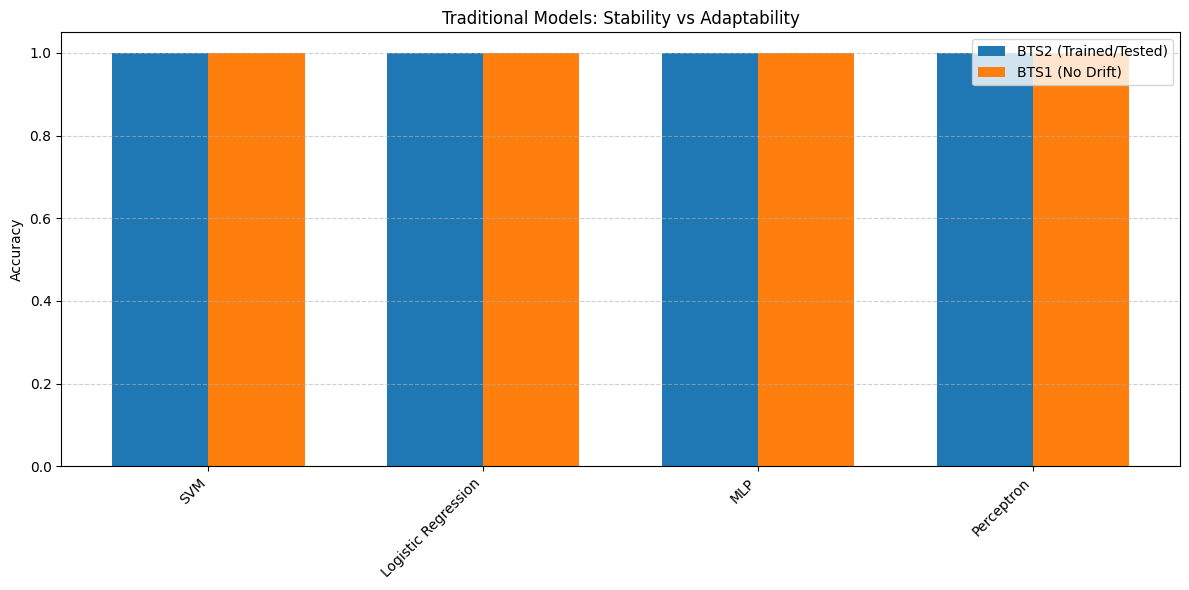

In [6]:
# CELL 6 - bar chart comparing accuracies on BTS2 vs BTS1 for all models
import numpy as np
x = np.arange(len(models))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - bar_width/2, list(results_bts2.values()), width=bar_width, label="BTS2 (Trained/Tested)")
plt.bar(x + bar_width/2, list(results_bts1.values()), width=bar_width, label="BTS1 (No Drift)")

plt.xticks(x, list(models.keys()), rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.title("Traditional Models: Stability vs Adaptability")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Applying drift strength: 0.0
SVM: accuracy after drift 0.0 = 0.9999
Logistic Regression: accuracy after drift 0.0 = 1.0000
MLP: accuracy after drift 0.0 = 1.0000
Perceptron: accuracy after drift 0.0 = 0.9996

Applying drift strength: 0.5
SVM: accuracy after drift 0.5 = 0.1476
Logistic Regression: accuracy after drift 0.5 = 0.7056
MLP: accuracy after drift 0.5 = 0.9988
Perceptron: accuracy after drift 0.5 = 0.9833

Applying drift strength: 1.0
SVM: accuracy after drift 1.0 = 0.9946
Logistic Regression: accuracy after drift 1.0 = 0.9996
MLP: accuracy after drift 1.0 = 0.9893
Perceptron: accuracy after drift 1.0 = 0.9222

Applying drift strength: 2.0
SVM: accuracy after drift 2.0 = 0.1453
Logistic Regression: accuracy after drift 2.0 = 0.5541
MLP: accuracy after drift 2.0 = 0.7729
Perceptron: accuracy after drift 2.0 = 0.7437


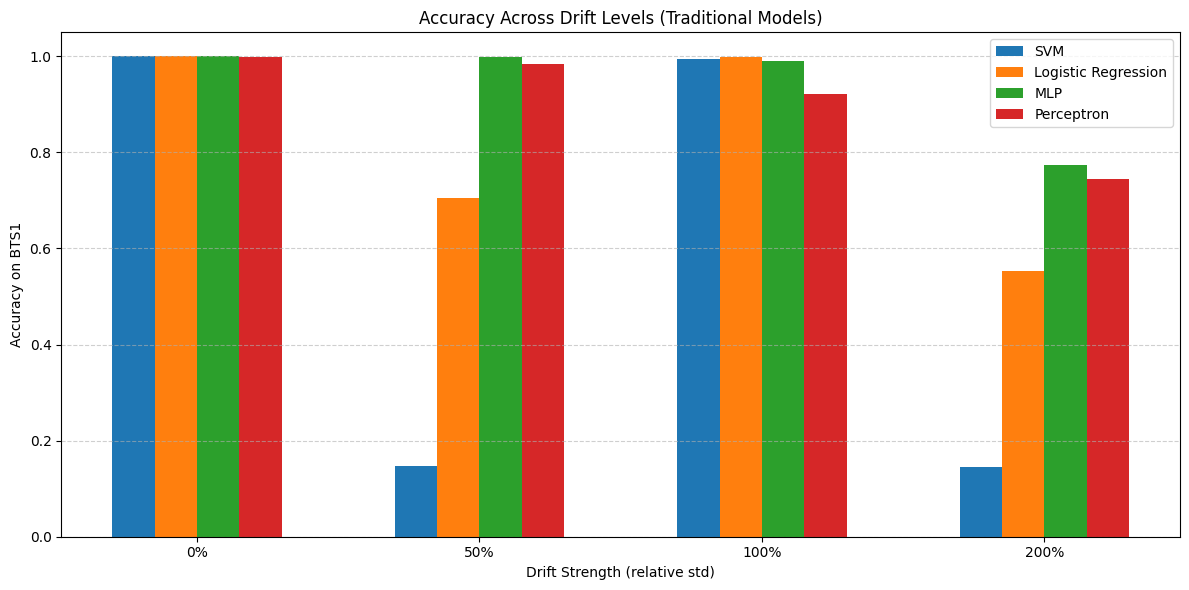

In [7]:
# CELL 7 - drift experiment (perturb numeric features in X1)
drift_levels = [0.0, 0.5, 1.0, 2.0]  # scaling of noise stdev
drift_results = {name: [] for name in models}

# detect numeric columns (from original X1 dataframe)
numeric_cols = X1.select_dtypes(include=['int64', 'float64']).columns.tolist()
if len(numeric_cols) == 0:
    numeric_cols = X1.columns.tolist()

for drift_strength in drift_levels:
    print(f"\nApplying drift strength: {drift_strength}")
    X1_drifted = X1.copy()

    n_drift = max(1, int(0.3 * len(numeric_cols)))
    drift_cols = np.random.choice(numeric_cols, n_drift, replace=False)

    for col in drift_cols:
        col_values = X1_drifted[col].astype(float).values
        noise = np.random.normal(loc=0.0, scale=drift_strength * np.std(col_values), size=len(col_values))
        X1_drifted[col] = col_values + noise

    X1_drifted_scaled = scaler.transform(X1_drifted)

    for name, model in models.items():
        acc = accuracy_score(y1, model.predict(X1_drifted_scaled))
        drift_results[name].append(acc)
        print(f"{name}: accuracy after drift {drift_strength} = {acc:.4f}")

# Plot drift results
plt.figure(figsize=(12, 6))
drift_labels = [f"{int(d*100)}%" for d in drift_levels]
x = np.arange(len(drift_labels))
width = 0.15

for i, (name, accs) in enumerate(drift_results.items()):
    plt.bar(x + i*width, accs, width=width, label=name)

plt.xticks(x + width*(len(models)-1)/2, drift_labels)
plt.ylabel("Accuracy on BTS1")
plt.xlabel("Drift Strength (relative std)")
plt.title("Accuracy Across Drift Levels (Traditional Models)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [8]:
# CELL 8 - produce static-MLP summary block (useful for copying into comparison)
mlp_name = "MLP"
acc_old_static = metrics_dict[mlp_name]['accuracy_data']['BTS2 (Old)']
acc_new_static = metrics_dict[mlp_name]['accuracy_data']['BTS1 (New)']
forgetting_rate_static = metrics_dict[mlp_name]['metrics_data']['Forgetting Rate']
overall_auroc_static = metrics_dict[mlp_name]['metrics_data']['AUROC']
overall_f1_static = metrics_dict[mlp_name]['metrics_data']['F1-Score']

print("\n=============================================")
print(f"| FINAL RESULTS FOR COMPARISON GRAPH ({mlp_name}) |")
print("=============================================")
print(f"BTS2 Acc (Old, Final): {acc_old_static:.4f}")
print(f"BTS1 Acc (New, Final): {acc_new_static:.4f}")
print(f"Forgetting Rate (Static Drop): {forgetting_rate_static:.4f}")
print(f"Overall AUROC: {overall_auroc_static}")
print(f"Overall F1-Score: {overall_f1_static}")
print("=============================================")



| FINAL RESULTS FOR COMPARISON GRAPH (MLP) |
BTS2 Acc (Old, Final): 1.0000
BTS1 Acc (New, Final): 1.0000
Forgetting Rate (Static Drop): 0.0000
Overall AUROC: 1.0
Overall F1-Score: 1.0
